# **Zomato Dataset Exploratory Data Analysis**

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
df = pd.read_csv('/content/zomato.csv',encoding='latin-1')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# **Data Wrangling**

In [132]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [134]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,9.051128e+06,8.791521e+06,53.000000,301962.500000,6.004089e+06,1.835229e+07,1.850065e+07
Country Code,9551.0,1.836562e+01,5.675055e+01,1.000000,1.000000,1.000000e+00,1.000000e+00,2.160000e+02
Longitude,9551.0,6.412657e+01,4.146706e+01,-157.948486,77.081343,7.719196e+01,7.728201e+01,1.748321e+02
Latitude,9551.0,2.585438e+01,1.100794e+01,-41.330428,28.478713,2.857047e+01,2.864276e+01,5.597698e+01
Average Cost for two,9551.0,1.199211e+03,1.612118e+04,0.000000,250.000000,4.000000e+02,7.000000e+02,8.000000e+05
Price range,9551.0,1.804837e+00,9.056088e-01,1.000000,1.000000,2.000000e+00,2.000000e+00,4.000000e+00
Aggregate rating,9551.0,2.666370e+00,1.516378e+00,0.000000,2.500000,3.200000e+00,3.700000e+00,4.900000e+00
Votes,9551.0,1.569097e+02,4.301691e+02,0.000000,5.000000,3.100000e+01,1.310000e+02,1.093400e+04


1. Missing Values
2. Explore the Numerical and Categorical values
3. Find relation between Features


In [135]:
# Missing Values
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [136]:
df.dropna(inplace = True)

In [137]:
# Numerical Columns

df_numerical = df.select_dtypes(include = ['int64','float64']).columns
df_numerical


Index(['Restaurant ID', 'Country Code', 'Longitude', 'Latitude',
       'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')

In [138]:
# Categorical Columns

df_categorical  = df.select_dtypes(include = ['object']).columns
df_categorical

Index(['Restaurant Name', 'City', 'Address', 'Locality', 'Locality Verbose',
       'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Switch to order menu', 'Rating color',
       'Rating text'],
      dtype='object')

In [139]:
df_country = pd.read_excel('/content/Country-Code.xlsx')
df_country.head()

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [140]:
final_df = pd.merge(df,df_country, on = 'Country Code', how = 'left')
final_df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [141]:
country_counts = final_df.Country.value_counts()
country_counts = country_counts.reset_index()
country_counts.columns = ['country_names','counts']
country_counts

,country_names,counts
0,India,8652
1,United States,425
2,United Kingdom,80
3,Brazil,60
4,South Africa,60
5,UAE,60
6,New Zealand,40
7,Turkey,34
8,Australia,24
9,Phillipines,22


In [142]:
country_names = country_counts.country_names.tolist()
country_names

['India',
 'United States',
 'United Kingdom',
 'Brazil',
 'South Africa',
 'UAE',
 'New Zealand',
 'Turkey',
 'Australia',
 'Phillipines',
 'Indonesia',
 'Qatar',
 'Singapore',
 'Sri Lanka',
 'Canada']

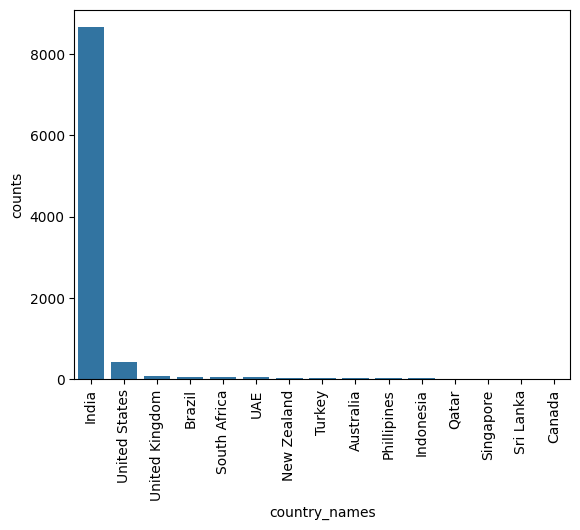

In [ ]:
sns.barplot(data = country_counts, x = 'country_names',y = 'counts')
plt.xticks(rotation = 90)
plt.show()

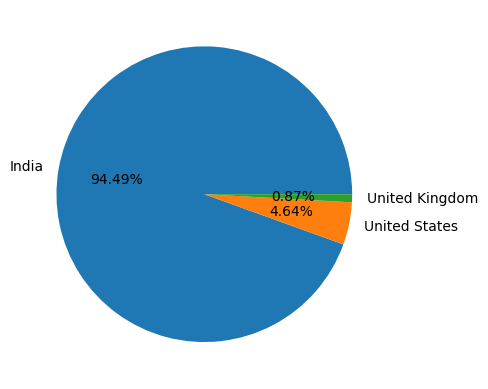

In [ ]:
# Pie chart

plt.pie(country_counts.counts[:3],labels = country_names[:3],autopct = '%1.2f%%')
plt.show()

Observation: Maximum top 3 Transaction countries

In [ ]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [ ]:
final_df['Restaurant Name'].nunique()

7437

In [ ]:
ratings = final_df.groupby(['Aggregate rating','Rating color','Rating text']).size().reset_index().rename(columns={0:'Rating Count'})
# Size = it counts the rating given by

ratings

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191


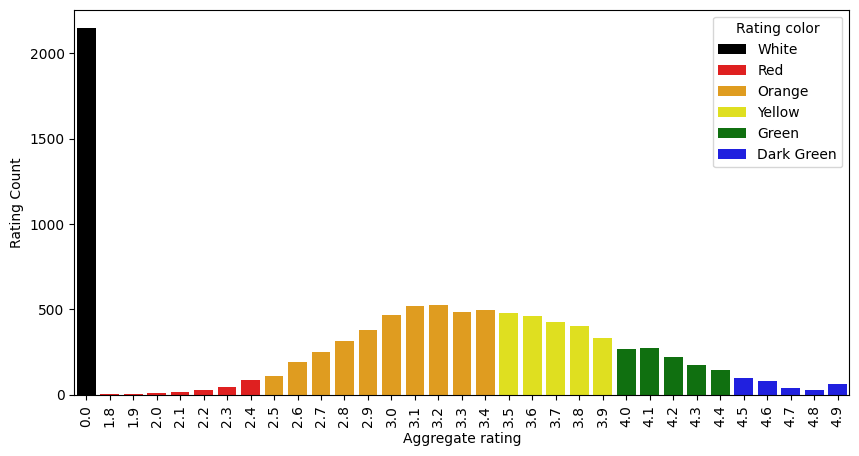

In [ ]:
plt.figure(figsize = (10,5))
sns.barplot(x = 'Aggregate rating',y = 'Rating Count',data = ratings,hue = 'Rating color',palette = ['Black','Red','Orange','Yellow','Green','blue'])
plt.xticks(rotation = 90)
plt.show()

In [ ]:
## Finding the countries that has given 0 ratings
zero_rating_countries = final_df[final_df['Aggregate rating'] == 0.0].groupby('Country').size().reset_index().rename(columns = {0:'Count of restaurents'})
zero_rating_countries


,Country,Count of restaurents
0,Brazil,5
1,India,2139
2,United Kingdom,1
3,United States,3


Observations : Maximum 0 ratings is from India

([<matplotlib.patches.Wedge at 0x7d7fb7c34830>,
 [Text(1.0999705874963337, 0.008044043943858627, 'Brazil'),
  Text(-1.0999988235261808, -0.0016088011121384329, 'India'),
  Text(1.0999423513968916, -0.011261598619968765, 'United Kingdom'),
  Text(1.0999894115590045, -0.004826433266405049, 'United States')],
 [Text(0.599983956816182, 0.004387660333013796, '0.23%'),
  Text(-0.5999993582870077, -0.000877527879348236, '99.58%'),
  Text(0.5999685553073953, -0.006142690156346598, '0.05%'),
  Text(0.5999942244867297, -0.0026325999634936627, '0.14%')])

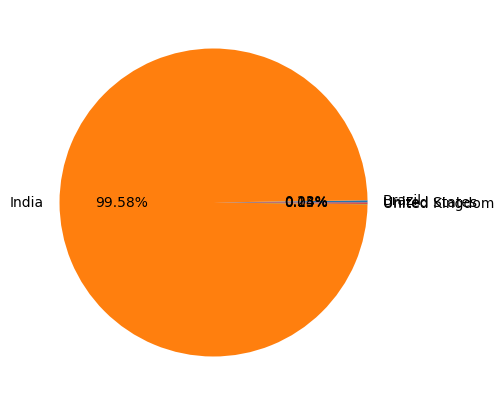

In [ ]:
# Plot
plt.figure(figsize = (10,5))
plt.pie(zero_rating_countries['Count of restaurents'],labels = zero_rating_countries['Country'],autopct='%1.2f%%')

In [ ]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [ ]:
# Finding Out which Currency is used in which country
final_df.groupby('Country')['Currency'].value_counts().reset_index(name = 'count')

,Country,Currency,count
0,Australia,Dollar($),24
1,Brazil,Brazilian Real(R$),60
2,Canada,Dollar($),4
3,India,Indian Rupees(Rs.),8652
4,Indonesia,Indonesian Rupiah(IDR),21
5,New Zealand,NewZealand($),40
6,Phillipines,Botswana Pula(P),22
7,Qatar,Qatari Rial(QR),20
8,Singapore,Dollar($),20
9,South Africa,Rand(R),60


In [ ]:
# Which countries have online deliveries
online_deliveries = final_df.groupby('Country')['Has Online delivery'].value_counts().reset_index(name = 'count')
online_deliveries

,Country,Has Online delivery,count
0,Australia,No,24
1,Brazil,No,60
2,Canada,No,4
3,India,No,6229
4,India,Yes,2423
5,Indonesia,No,21
6,New Zealand,No,40
7,Phillipines,No,22
8,Qatar,No,20
9,Singapore,No,20


In [ ]:
# Creat a piechart for cities distribution
cities_distribution = final_df.City.value_counts().reset_index()
cities_distribution


,City,count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
...,...,...
135,Inverloch,1
136,Mohali,1
137,Panchkula,1
138,Bandung,1


In [ ]:
City_values = final_df.City.value_counts().values
City_values

array([5473, 1118, 1080,  251,   25,   21,   21,   21,   21,   21,   20,
         20,   20,   20,   20,   20,   20,   20,   20,   20,   20,   20,
         20,   20,   20,   20,   20,   20,   20,   20,   20,   20,   20,
         20,   20,   20,   20,   20,   20,   20,   20,   20,   20,   20,
         20,   20,   20,   20,   20,   20,   20,   20,   20,   20,   20,
         20,   20,   20,   20,   20,   20,   20,   20,   20,   20,   20,
         20,   20,   20,   20,   20,   19,   19,   19,   19,   19,   18,
         18,   17,   16,   14,   11,    6,    4,    4,    3,    3,    2,
          2,    2,    2,    2,    2,    2,    2,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1])

In [ ]:
City_labels = final_df.City.value_counts().index
City_labels

Index(['New Delhi', 'Gurgaon', 'Noida', 'Faridabad', 'Ghaziabad',
       'Bhubaneshwar', 'Ahmedabad', 'Lucknow', 'Guwahati', 'Amritsar',
       ...
       'Forrest', 'Dicky Beach', 'Flaxton', 'Huskisson', 'Lakes Entrance',
       'Inverloch', 'Mohali', 'Panchkula', 'Bandung', 'Randburg'],
      dtype='object', name='City', length=140)

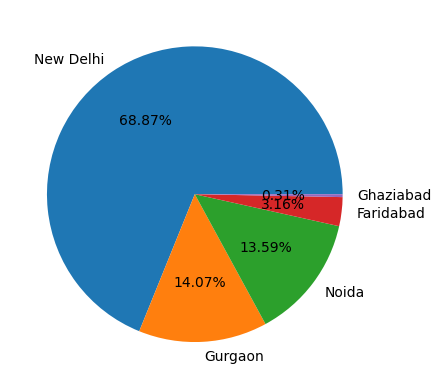

In [ ]:
plt.pie(City_values[:5],labels = City_labels[:5],autopct = '%1.2f%%')
plt.show()

In [ ]:
# Find top 10 cuisines
cuisines = final_df.Cuisines.value_counts().reset_index()
cuisines

,Cuisines,count
0,North Indian,936
1,"North Indian, Chinese",511
2,Chinese,354
3,Fast Food,354
4,"North Indian, Mughlai",334
...,...,...
1820,"World Cuisine, Patisserie, Cafe",1
1821,"Burger, Izgara",1
1822,"Desserts, Bí_rek",1
1823,"Restaurant Cafe, Turkish, Desserts",1


In [ ]:
cuisines_counts = final_df.Cuisines.value_counts().values
cuisines_label = final_df.Cuisines.value_counts().index

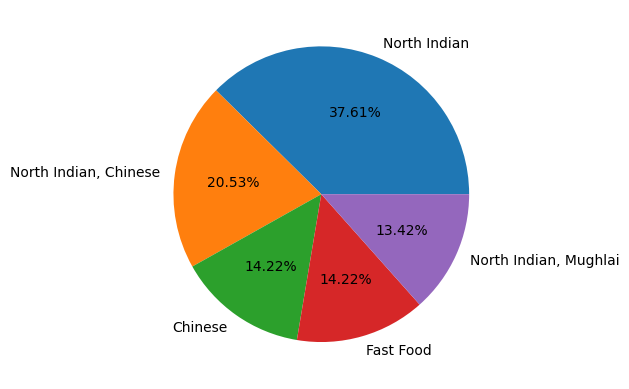

In [ ]:
plt.pie(cuisines_counts[:5],labels = cuisines_label[:5],autopct = '%1.2f%%')
plt.show()

#**Black Friday Dataset EDA and Feature engineering**

**Cleaning and preparing the data for Model Training**

In [ ]:
import numpy as np
import pandas as pdz
import matplotlib.pyplot as plt
import seaborn as sns

A retail company “ABC Private Limited” wants to understand the customer purchase behaviour (specifically, purchase amount) against various products of different categories. They have shared purchase summary of various customers for selected high volume products from last month. The data set also contains customer demographics (age, gender, marital status, city_type, stay_in_current_city), product details (product_id and product category) and Total purchase_amount from last month.

Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customers against different products.

In [ ]:
# Import training dataset

df_train = pd.read_csv('/content/train.csv')
df_train.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [ ]:
df_train.shape

(550068, 12)

In [ ]:
# Import test dataset

df_test = pd.read_csv('/content/black_test.csv')
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


In [ ]:
df_test.shape

(233599, 11)

In [ ]:
# Concatinating the datasets
df = pd.concat([df_train,df_test],axis = 0)
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [ ]:
df.shape

(783667, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 783667 entries, 0 to 233598
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 77.7+ MB


In [ ]:
df1 = df.copy()

In [ ]:
df1.drop(['User_ID'],axis = 1,inplace=True)

In [ ]:
df1.isnull().sum()

,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,245982
Product_Category_3,545809


In [ ]:
categorical_features = df1.select_dtypes(include = 'object').columns
categorical_features

Index(['Product_ID', 'Gender', 'Age', 'City_Category',
       'Stay_In_Current_City_Years'],
      dtype='object')

In [ ]:
numerical_features = df1.select_dtypes(include = ['int64','float64']).columns
numerical_features

Index(['Occupation', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [ ]:
pd.get_dummies(df1['Gender']).astype('int')

,F,M
0,1,0
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
233594,1,0
233595,1,0
233596,1,0
233597,1,0


In [ ]:
# Converting object features in numerical values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for feature in categorical_features:
  df1[feature] = le.fit_transform(df1[feature])

In [ ]:
df1.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,684,0,0,10,0,2,0,3,NaN,NaN,8370.0
1,2406,0,0,10,0,2,0,1,6.0,14.0,15200.0
2,868,0,0,10,0,2,0,12,NaN,NaN,1422.0
3,844,0,0,10,0,2,0,12,14.0,NaN,1057.0
4,2769,1,6,16,2,4,0,8,NaN,NaN,7969.0


In [ ]:
# Fixing the null values
df1.isnull().sum()

,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,245982
Product_Category_3,545809


In [ ]:
# For Product_Category_2

In [ ]:
df1['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [ ]:
df1['Product_Category_2'].value_counts()

,count
Product_Category_2,
8.0,91317
14.0,78834
2.0,70498
16.0,61687
15.0,54114
5.0,37165
4.0,36705
6.0,23575
11.0,20230


In [ ]:
df1['Product_Category_2'].mode()

,Product_Category_2
0,8.0


In [ ]:
df1['Product_Category_2'] = df1['Product_Category_2'].fillna(df1['Product_Category_2']).mode()[0]

In [ ]:
df1['Product_Category_2'].isnull().sum()

np.int64(0)

In [ ]:
# For Product_category_3

In [ ]:
df1['Product_Category_3'].unique()

array([nan, 14., 17.,  5.,  4., 16., 15.,  8.,  9., 13.,  6., 12.,  3.,
       18., 11., 10.])

In [ ]:
df1['Product_Category_3'].value_counts()

,count
Product_Category_3,
16.0,46469
15.0,39968
14.0,26283
17.0,23818
5.0,23799
8.0,17861
9.0,16532
12.0,13115
13.0,7849


In [ ]:
df1['Product_Category_3'].mode()

,Product_Category_3
0,16.0


In [ ]:
df1['Product_Category_3'] = df1['Product_Category_3'].fillna(df1['Product_Category_3']).mode()[0]

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 783667 entries, 0 to 233598
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  int64  
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   City_Category               783667 non-null  int64  
 5   Stay_In_Current_City_Years  783667 non-null  int64  
 6   Marital_Status              783667 non-null  int64  
 7   Product_Category_1          783667 non-null  int64  
 8   Product_Category_2          783667 non-null  float64
 9   Product_Category_3          783667 non-null  float64
 10  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(8)
memory usage: 71.7 MB


#**Visualization**

In [ ]:
df1.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,684,0,0,10,0,2,0,3,8.0,16.0,8370.0
1,2406,0,0,10,0,2,0,1,8.0,16.0,15200.0
2,868,0,0,10,0,2,0,12,8.0,16.0,1422.0
3,844,0,0,10,0,2,0,12,8.0,16.0,1057.0
4,2769,1,6,16,2,4,0,8,8.0,16.0,7969.0


In [ ]:
# Age vs Purchase

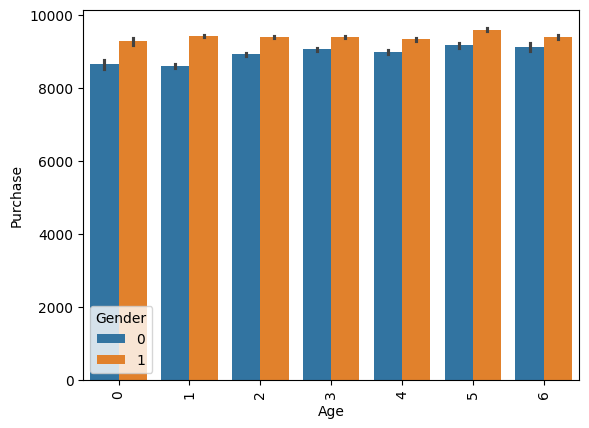

In [ ]:
sns.barplot(x = 'Age',y = 'Purchase',data = df1,hue = 'Gender')
plt.xticks(rotation = 90)
plt.show()

**Observation:** Purchase of mens are higher than women

In [ ]:
# Occupation vs Purchase

In [ ]:
df['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

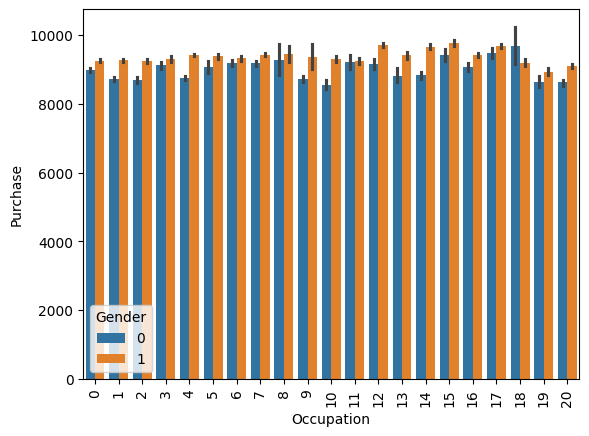

In [ ]:
sns.barplot(x = 'Occupation',y = 'Purchase',data = df1,hue = 'Gender')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Product_Category_1 vs Purchase

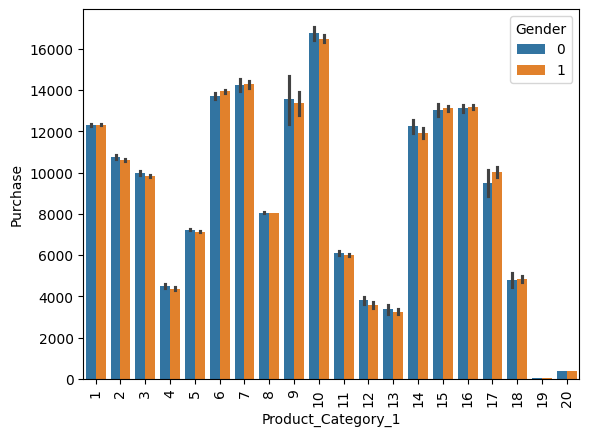

In [ ]:
sns.barplot(x = 'Product_Category_1',y = 'Purchase',data = df1,hue = 'Gender')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Product_Category_2 vs Purchase

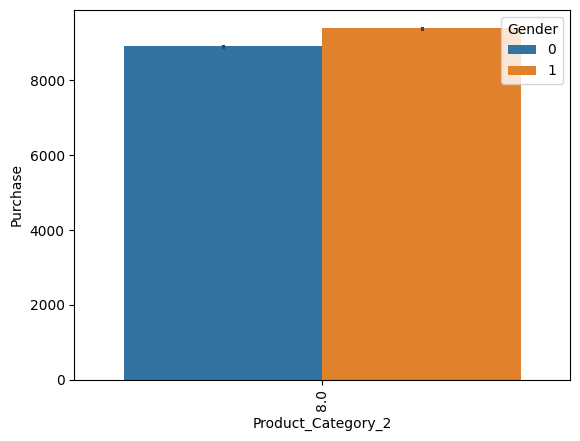

In [ ]:
sns.barplot(x = 'Product_Category_2',y = 'Purchase',data = df1,hue = 'Gender')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Product_Category_3 vs Purchase

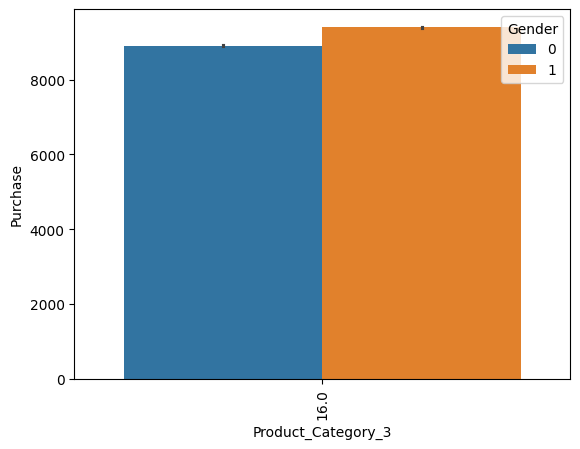

In [ ]:
sns.barplot(x = 'Product_Category_3',y = 'Purchase',data = df1,hue = 'Gender')
plt.xticks(rotation = 90)
plt.show()

#**Feature Engineering**

In [ ]:
# Feature Scaling

In [ ]:
df1 = df1.drop('Product_ID',axis = 1)

In [ ]:
df_test = df1[df1['Purchase'].isnull()]
df_train = df1[~df1['Purchase'].isnull()]

In [ ]:
x = df_train.drop('Purchase',axis = 1)
y = df_train['Purchase']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 0)

In [ ]:
x.head()

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,0,0,10,0,2,0,3,8.0,16.0
1,0,0,10,0,2,0,1,8.0,16.0
2,0,0,10,0,2,0,12,8.0,16.0
3,0,0,10,0,2,0,12,8.0,16.0
4,1,6,16,2,4,0,8,8.0,16.0


In [ ]:
x.shape

(550068, 9)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#**Flight Price Prediction(EDA + Feature Engineering)**

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
df_train = pd.read_excel('/content/Flight_Train_set.xlsx')
df_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [145]:
df_test = pd.read_excel('/content/Flight_Test_set.xlsx')
df_test.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [146]:
df_final = pd.concat([df_train,df_test],axis = 0)
df_final.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0


In [147]:
df1 = df_final.copy()

In [148]:
df_final.shape

(13354, 11)

In [149]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.7+ MB


#**Feature Engineering**

**Feature Extraction**

In [150]:
# Extracting the features

In [151]:
df_final['Date_of_Journey'] = pd.to_datetime(df_final['Date_of_Journey'])


/tmp/ipython-input-2293860467.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_final['Date_of_Journey'] = pd.to_datetime(df_final['Date_of_Journey'])


In [152]:
df_final['Date_of_Journey'].dtype


dtype('<M8[ns]')

In [153]:
df_final['Date'] = df_final['Date_of_Journey'].dt.day
df_final['Month'] = df_final['Date_of_Journey'].dt.month
df_final['Year'] = df_final['Date_of_Journey'].dt.year

In [154]:
df_final.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,1,3,2019


In [155]:
df_final.drop('Date_of_Journey',axis = 1)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,1,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,Air India,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,NaN,6,6,2019
2667,IndiGo,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,NaN,27,3,2019
2668,Jet Airways,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,NaN,6,3,2019
2669,Air India,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,NaN,6,3,2019


In [156]:
# Extracting the features ---> M2

In [157]:
df1['Date'] = df1['Date_of_Journey'].apply(lambda x:x.split('/')[0]).astype(int)

In [158]:
df1['month'] = df1['Date_of_Journey'].apply(lambda x:x.split('/')[1]).astype(int)

In [159]:
df1['year'] = df1['Date_of_Journey'].apply(lambda x: x.split('/')[2]).astype(int)

In [160]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,month,year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,3,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,5,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,9,6,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,12,5,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,1,3,2019


In [161]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
 11  Date             13354 non-null  int64  
 12  month            13354 non-null  int64  
 13  year             13354 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 2.0+ MB


In [162]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          13354 non-null  object        
 1   Date_of_Journey  13354 non-null  datetime64[ns]
 2   Source           13354 non-null  object        
 3   Destination      13354 non-null  object        
 4   Route            13353 non-null  object        
 5   Dep_Time         13354 non-null  object        
 6   Arrival_Time     13354 non-null  object        
 7   Duration         13354 non-null  object        
 8   Total_Stops      13353 non-null  object        
 9   Additional_Info  13354 non-null  object        
 10  Price            10683 non-null  float64       
 11  Date             13354 non-null  int32         
 12  Month            13354 non-null  int32         
 13  Year             13354 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), 

In [163]:
# Arrival_time

In [164]:
df_final['Arrival_Time'] = df_final['Arrival_Time'].str.split(' ').str[0]

In [165]:
df_final['Arrival_Time']

,Arrival_Time
0,01:10
1,13:15
2,04:25
3,23:30
4,21:35
...,...
2666,20:25
2667,16:55
2668,04:25
2669,19:15


In [166]:
df_final['Hours'] = df_final['Arrival_Time'].apply(lambda x:x.split(':')[0]).astype(int)

In [167]:
df_final['Minutes'] = df_final['Arrival_Time'].apply(lambda x:x.split(':')[1]).astype(int)

In [168]:
df_final.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Hours,Minutes
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882.0,9,6,2019,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,12,5,2019,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,1,3,2019,21,35


In [169]:
df_final.drop('Arrival_Time',axis = 1,inplace = True)

In [170]:
# Dep_Time

In [171]:
df_final['Dep_Time'] = pd.to_datetime(df_final['Dep_Time'])

/tmp/ipython-input-1563998006.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final['Dep_Time'] = pd.to_datetime(df_final['Dep_Time'])


In [172]:
df_final['Dep_Hours'] = df_final['Dep_Time'].dt.hour
df_final['Dep_Minutes'] = df_final['Dep_Time'].dt.minute

In [173]:
df_final.drop('Dep_Time',axis = 1,inplace = True)

In [174]:
# Total Stops

In [175]:
df_final['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [176]:
df_final['Total_Stops'].value_counts()

,count
Total_Stops,
1 stop,7056
non-stop,4340
2 stops,1899
3 stops,56
4 stops,2


In [177]:
# Mapping the stops

In [178]:
df_final['Total_Stops'] = df_final['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})

In [179]:
df_final['Total_Stops']

,Total_Stops
0,0.0
1,2.0
2,2.0
3,1.0
4,1.0
...,...
2666,1.0
2667,0.0
2668,1.0
2669,1.0


In [180]:
df_final.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Hours,Minutes,Dep_Hours,Dep_Minutes
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,0.0,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2.0,No info,7662.0,1,5,2019,13,15,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2.0,No info,13882.0,9,6,2019,4,25,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1.0,No info,6218.0,12,5,2019,23,30,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1.0,No info,13302.0,1,3,2019,21,35,16,50


In [181]:
# Checking for null values

In [182]:
df_final.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Duration,0
Total_Stops,1
Additional_Info,0
Price,2671
Date,0


In [183]:
df_final.drop('Route',axis=1,inplace = True)

In [184]:
def convert_duration_to_minutes(df,duration_col):
  df['Duration_minutes'] = df[duration_col].apply(lambda x: int(x.split('h')[0]) * 60 if 'h' in x and 'm' not in x else
                                                    int(x.split('m')[0].split(' ')[-1]) if 'm' in x and 'h'  not in x else
                                                    int(x.split('h')[0]) * 60 + int(x.split('m')[0].split(' ')[-1]) if 'h' in x and 'm' in x else pd.NA)


  # .split(' ')[-1]: This splits the result at spaces and takes the last element.
  # This is necessary to handle cases where there might be spaces before the minute value.
  # pd.NA (Pandas' missing value representation)

In [185]:
convert_duration_to_minutes(df_final,duration_col = 'Duration')

In [186]:
df_final['Duration_minutes']

,Duration_minutes
0,170
1,445
2,1140
3,325
4,285
...,...
2666,1435
2667,155
2668,395
2669,915


In [187]:
df_final.drop(['Duration','Date_of_Journey'],axis = 1,inplace = True)

In [188]:
# Remaining Categorical Columns

In [189]:
df_final['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [190]:
len(df_final['Airline'].unique())

12

In [191]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_final['Airline'] = le.fit_transform(df_final['Airline'])
df_final['Source'] = le.fit_transform(df_final['Source'])
df_final['Destination'] = le.fit_transform(df_final['Destination'])
df_final['Additional_Info'] = le.fit_transform(df_final['Additional_Info'])

In [192]:
df_final.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Hours,Minutes,Dep_Hours,Dep_Minutes,Duration_minutes
0,3,0,5,0.0,8,3897.0,24,3,2019,1,10,22,20,170
1,1,3,0,2.0,8,7662.0,1,5,2019,13,15,5,50,445
2,4,2,1,2.0,8,13882.0,9,6,2019,4,25,9,25,1140
3,3,3,0,1.0,8,6218.0,12,5,2019,23,30,18,5,325
4,3,0,5,1.0,8,13302.0,1,3,2019,21,35,16,50,285


In [194]:
df_final.shape

(13354, 14)